# Phase 1 — Data Exploration Notebook
## Precision Agronomy Recommender | Pilot Crop: Paddy (Rice)

**Objective:** Load raw datasets, verify quality, understand distributions, identify missing values.
This notebook is the evidence base for the Phase 1 data summary report.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import json
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

print("✅ All imports successful")
print(f"   pandas  {pd.__version__}")
print(f"   numpy   {np.__version__}")

✅ All imports successful
   pandas  3.0.3
   numpy   2.3.1


---
## Section 1: Crop Recommendation Dataset (NPK Baseline)
**Source:** Kaggle — Atharva Ingle / ICFA  
**File:** `data/raw/crop_recommendation.csv`

In [2]:
# Load the dataset
df = pd.read_csv('../data/raw/crop_recommendation.csv')

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nCrops in dataset: {sorted(df['label'].unique())}")
print(f"\nTotal crops: {df['label'].nunique()}")

Shape: (2200, 8)
Columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']

Crops in dataset: ['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'pomegranate', 'rice', 'watermelon']

Total crops: 22


In [3]:
# Filter to Paddy (Rice) only — our pilot crop
paddy_df = df[df['label'] == 'rice'].copy().reset_index(drop=True)

print(f"Total records: {len(df)}")
print(f"Paddy records: {len(paddy_df)} ({len(paddy_df)/len(df)*100:.1f}% of dataset)")
print()
print("── Paddy NPK statistics ──────────────────────────")
print(paddy_df[['N','P','K','ph','temperature','humidity','rainfall']].describe().round(2))

Total records: 2200
Paddy records: 100 (4.5% of dataset)

── Paddy NPK statistics ──────────────────────────
            N       P       K      ph  temperature  humidity  rainfall
count  100.00  100.00  100.00  100.00       100.00    100.00    100.00
mean    79.89   47.58   39.87    6.43        23.69     82.27    236.18
std     11.92    7.90    2.95    0.77         2.03      1.42     34.29
min     60.00   35.00   35.00    5.01        20.05     80.12    182.56
25%     69.00   41.00   38.00    5.87        21.93     80.95    204.33
50%     80.00   47.00   40.00    6.36        23.73     82.19    233.12
75%     91.00   54.25   42.00    7.04        25.51     83.47    264.13
max     99.00   60.00   45.00    7.87        26.93     84.97    298.56


In [4]:
# Check for missing values
print("Missing values in paddy dataset:")
missing = paddy_df.isnull().sum()
print(missing)
print()
if missing.sum() == 0:
    print("✅ No missing values in Kaggle dataset")
    print("⚠️  NOTE: This dataset lacks micronutrients (Zn, B, S, Fe, Mn, Cu)")
    print("   These will need KNN imputation using SHC data in Phase 2")
else:
    print(f"⚠️  {missing.sum()} missing values found — review before Phase 2")

Missing values in paddy dataset:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

✅ No missing values in Kaggle dataset
⚠️  NOTE: This dataset lacks micronutrients (Zn, B, S, Fe, Mn, Cu)
   These will need KNN imputation using SHC data in Phase 2


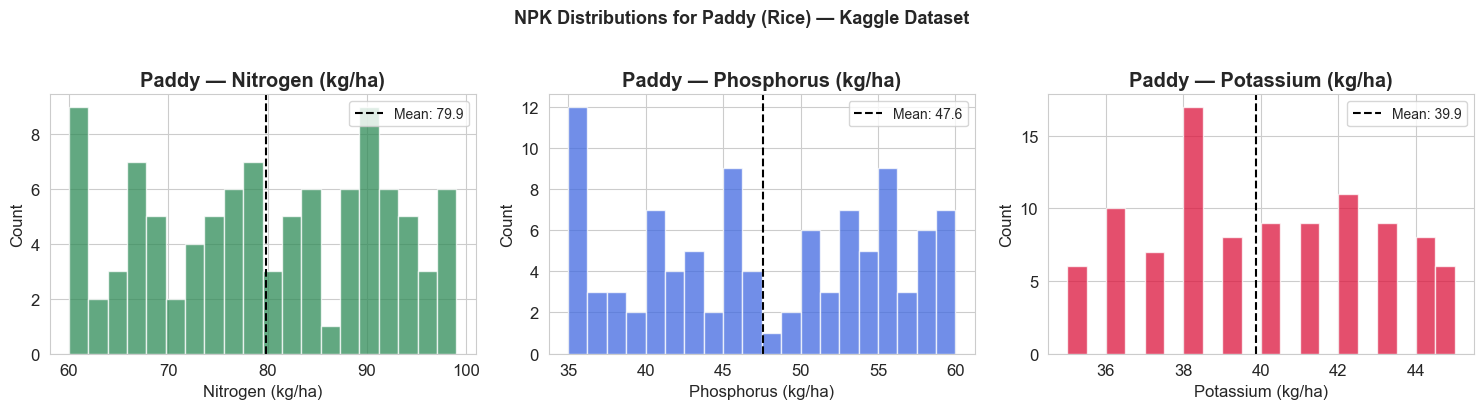

✅ Plot saved to data/processed/paddy_npk_distributions.png


In [5]:
# NPK Distribution plots for Paddy
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

features = [('N', 'Nitrogen (kg/ha)', '#2E8B57'),
            ('P', 'Phosphorus (kg/ha)', '#4169E1'),
            ('K', 'Potassium (kg/ha)', '#DC143C')]

for ax, (col, label, color) in zip(axes, features):
    ax.hist(paddy_df[col], bins=20, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(paddy_df[col].mean(), color='black', linestyle='--', linewidth=1.5, label=f'Mean: {paddy_df[col].mean():.1f}')
    ax.set_title(f'Paddy — {label}', fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.legend(fontsize=10)

plt.suptitle('NPK Distributions for Paddy (Rice) — Kaggle Dataset', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/paddy_npk_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved to data/processed/paddy_npk_distributions.png")

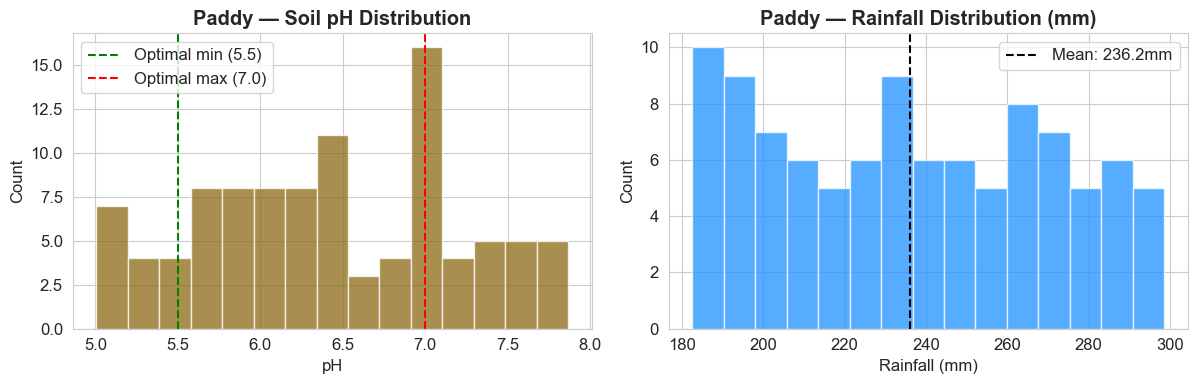

In [6]:
# pH and rainfall distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(paddy_df['ph'], bins=15, color='#8B6914', alpha=0.75, edgecolor='white')
axes[0].axvline(5.5, color='green', linestyle='--', label='Optimal min (5.5)')
axes[0].axvline(7.0, color='red', linestyle='--', label='Optimal max (7.0)')
axes[0].set_title('Paddy — Soil pH Distribution', fontweight='bold')
axes[0].set_xlabel('pH')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(paddy_df['rainfall'], bins=15, color='#1E90FF', alpha=0.75, edgecolor='white')
axes[1].axvline(paddy_df['rainfall'].mean(), color='black', linestyle='--', label=f"Mean: {paddy_df['rainfall'].mean():.1f}mm")
axes[1].set_title('Paddy — Rainfall Distribution (mm)', fontweight='bold')
axes[1].set_xlabel('Rainfall (mm)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/paddy_ph_rainfall.png', dpi=150, bbox_inches='tight')
plt.show()

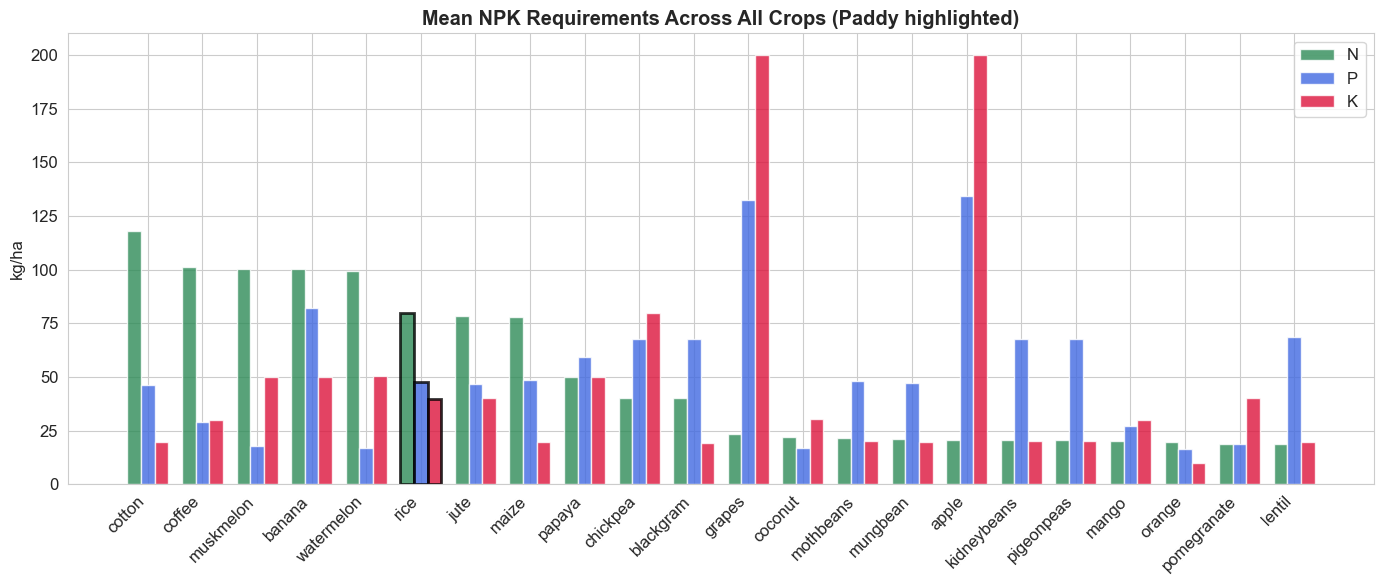

In [7]:
# Compare Paddy NPK vs all other crops — context for recommendation
crop_stats = df.groupby('label')[['N','P','K']].mean().sort_values('N', ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(crop_stats))
width = 0.25

bars_n = ax.bar([i - width for i in x], crop_stats['N'], width, label='N', color='#2E8B57', alpha=0.8)
bars_p = ax.bar(x, crop_stats['P'], width, label='P', color='#4169E1', alpha=0.8)
bars_k = ax.bar([i + width for i in x], crop_stats['K'], width, label='K', color='#DC143C', alpha=0.8)

# Highlight paddy
paddy_idx = list(crop_stats.index).index('rice')
for bar_group in [bars_n, bars_p, bars_k]:
    bar_group[paddy_idx].set_edgecolor('black')
    bar_group[paddy_idx].set_linewidth(2)

ax.set_xticks(x)
ax.set_xticklabels(crop_stats.index, rotation=45, ha='right')
ax.set_title('Mean NPK Requirements Across All Crops (Paddy highlighted)', fontweight='bold')
ax.set_ylabel('kg/ha')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/all_crops_npk_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 2: Weather API Test — Open-Meteo
**Source:** Open-Meteo (no API key required)  
**Purpose:** Validate the 8-hour rain-free window logic for the spray decision engine

In [8]:
# Test Open-Meteo API — Pilot district: Noida/Greater Noida, UP
PILOT_LAT = 28.4595
PILOT_LNG = 77.5022

url = "https://api.open-meteo.com/v1/forecast"
params = {
    "latitude":  PILOT_LAT,
    "longitude": PILOT_LNG,
    "hourly":    "precipitation_probability,temperature_2m,relative_humidity_2m,wind_speed_10m",
    "forecast_days": 1,
    "timezone": "Asia/Kolkata"
}

response = requests.get(url, params=params)
print(f"API Status: {response.status_code}")

if response.status_code == 200:
    data = response.json()
    print(f"Location: {data.get('latitude')}, {data.get('longitude')}")
    print(f"Timezone: {data.get('timezone')}")
    print("✅ Open-Meteo API working")
else:
    print(f"❌ API Error: {response.text}")

API Status: 200
Location: 28.435852, 77.52273
Timezone: Asia/Kolkata
✅ Open-Meteo API working


In [9]:
# Extract next 8 hours and run the spray window logic
hourly = data["hourly"]

# Next 8 hours
rain_8h    = hourly["precipitation_probability"][:8]
temps_8h   = hourly["temperature_2m"][:8]
humidity_8h= hourly["relative_humidity_2m"][:8]
times_8h   = hourly["time"][:8]

print("── Next 8 Hours: Rain Probability ────────────────")
for t, r in zip(times_8h, rain_8h):
    bar = "█" * (r // 10)
    flag = " ⚠️ HIGH" if r >= 20 else ""
    print(f"  {t[-5:]}  {r:3d}%  {bar}{flag}")

print()
max_rain = max(rain_8h)
safe_to_spray = max_rain < 20
print(f"Max rain probability in 8h: {max_rain}%")
print(f"Safe to spray?  {'✅ YES — GO ahead' if safe_to_spray else '❌ NO — DELAY spray'}")
print()
print(f"Avg temperature: {sum(temps_8h)/len(temps_8h):.1f}°C")
print(f"Avg humidity:    {sum(humidity_8h)/len(humidity_8h):.1f}%")

── Next 8 Hours: Rain Probability ────────────────
  00:00    0%  
  01:00    0%  
  02:00    0%  
  03:00    0%  
  04:00    0%  
  05:00    0%  
  06:00    0%  
  07:00    0%  

Max rain probability in 8h: 0%
Safe to spray?  ✅ YES — GO ahead

Avg temperature: 26.3°C
Avg humidity:    66.4%


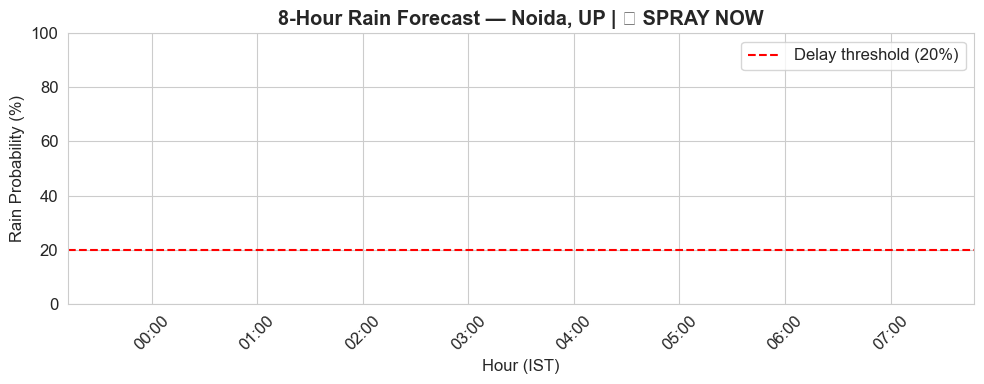

✅ This chart is what drives the /weather-check API endpoint in Phase 4


In [10]:
# Visualize the 8-hour window
fig, ax = plt.subplots(figsize=(10, 4))

colors = ['#DC143C' if r >= 20 else '#2E8B57' for r in rain_8h]
bars = ax.bar(range(8), rain_8h, color=colors, alpha=0.8, edgecolor='white', linewidth=0.5)
ax.axhline(20, color='red', linestyle='--', linewidth=1.5, label='Delay threshold (20%)')
ax.set_xticks(range(8))
ax.set_xticklabels([t[-5:] for t in times_8h], rotation=45)
ax.set_xlabel('Hour (IST)')
ax.set_ylabel('Rain Probability (%)')
ax.set_title(f'8-Hour Rain Forecast — Noida, UP | {"🟢 SPRAY NOW" if safe_to_spray else "🔴 DELAY SPRAY"}', fontweight='bold')
ax.set_ylim(0, 100)
ax.legend()

plt.tight_layout()
plt.savefig('../data/processed/weather_spray_window.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ This chart is what drives the /weather-check API endpoint in Phase 4")

---
## Section 3: IFFCO Nano Urea Specs — Rules Verification
**Source:** `data/raw/iffco_nano_urea_specs.json`

In [11]:
# Load and display IFFCO product rules
with open('../data/raw/iffco_nano_urea_specs.json') as f:
    specs = json.load(f)

nano_urea = specs['products']['nano_urea_plus']

print("── Nano Urea Plus — Key Specs ────────────────────")
print(f"  Nitrogen content : {nano_urea['specifications']['nitrogen_content']}")
print(f"  Particle size    : {nano_urea['specifications']['particle_size']}")
print(f"  Min dose         : {nano_urea['dosage']['min_ml_per_litre_water']} ml/L")
print(f"  Max dose         : {nano_urea['dosage']['max_ml_per_litre_water']} ml/L")
print()
print("── Paddy Application Windows ─────────────────────")
for w in nano_urea['application_windows']['paddy']:
    print(f"  Spray {w['spray_number']}: {w['stage']} — {w['timing']}")
print()
print("── Critical Rule ─────────────────────────────────")
print(f"  {nano_urea['constraints']['rule']}")
print()
print("── Environmental Impact ──────────────────────────")
ei = nano_urea['environmental_impact_vs_conventional_urea']
print(f"  N₂O reduction    : {ei['nitrous_oxide_reduction_pct']}%")
print(f"  NH₃ reduction    : {ei['ammonia_volatilization_reduction_pct']}%")

── Nano Urea Plus — Key Specs ────────────────────
  Nitrogen content : 20% (w/v)
  Particle size    : 20–50 nanometers (<100nm)
  Min dose         : 2.0 ml/L
  Max dose         : 4.0 ml/L

── Paddy Application Windows ─────────────────────
  Spray 1: Active Tillering — 30–35 Days After Transplanting (DAT)
  Spray 2: Pre-Flowering / Panicle Initiation — 45–55 Days After Transplanting (DAT)

── Critical Rule ─────────────────────────────────
  Only replaces top-dressed urea. Basal nitrogen at sowing is mandatory.

── Environmental Impact ──────────────────────────
  N₂O reduction    : 45%
  NH₃ reduction    : 70%


---
## Section 4: Phase 1 Data Summary



In [12]:
# Auto-generate Phase 1 summary stats for report
print("=" * 55)
print("  PHASE 1 DATA SUMMARY — for Intern Report")
print("=" * 55)
print()
print("DATASET 1: Kaggle Crop Recommendation")
print(f"  Total records       : {len(df)}")
print(f"  Paddy records       : {len(paddy_df)}")
print(f"  Features available  : {list(paddy_df.columns)}")
print(f"  Missing values      : {paddy_df.isnull().sum().sum()}")
print(f"  Missing features    : Zn, B, S, Fe, Mn, Cu (need KNN imputation)")
print()
print("DATASET 2: Weather API")
print(f"  Source              : Open-Meteo (dev), IMD (production)")
print(f"  Pilot location      : Noida, UP ({PILOT_LAT}, {PILOT_LNG})")
print(f"  Current spray safe? : {'YES' if safe_to_spray else 'NO'}")
print()
print("DATASET 3: IFFCO Rules Engine")
print(f"  Nano Urea dose range: 2.0 – 4.0 ml/L")
print(f"  Paddy spray windows : DAT 30–35 (tillering), DAT 45–55 (pre-flower)")
print(f"  Rain-free window    : 8 hours post-spray")
print()
print("NEXT STEPS (Phase 2):")
print("  1. Download SHC district data for Gautam Buddha Nagar")
print("  2. Download KCC pest query data (filter to Rice)")
print("  3. Build ETL pipeline to merge all sources")
print("  4. KNN imputation for missing micronutrients")
print("  5. GeoPandas spatial mapping of GPS → soil cluster")

  PHASE 1 DATA SUMMARY — for Intern Report

DATASET 1: Kaggle Crop Recommendation
  Total records       : 2200
  Paddy records       : 100
  Features available  : ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']
  Missing values      : 0
  Missing features    : Zn, B, S, Fe, Mn, Cu (need KNN imputation)

DATASET 2: Weather API
  Source              : Open-Meteo (dev), IMD (production)
  Pilot location      : Noida, UP (28.4595, 77.5022)
  Current spray safe? : YES

DATASET 3: IFFCO Rules Engine
  Nano Urea dose range: 2.0 – 4.0 ml/L
  Paddy spray windows : DAT 30–35 (tillering), DAT 45–55 (pre-flower)
  Rain-free window    : 8 hours post-spray

NEXT STEPS (Phase 2):
  1. Download SHC district data for Gautam Buddha Nagar
  2. Download KCC pest query data (filter to Rice)
  3. Build ETL pipeline to merge all sources
  4. KNN imputation for missing micronutrients
  5. GeoPandas spatial mapping of GPS → soil cluster


In [13]:
import pandas as pd

df = pd.read_csv('../data/raw/crop_recommendation.csv')
paddy = df[df['label'] == 'rice'].copy().reset_index(drop=True)

print(f"Total rows: {len(df)}")
print(f"Paddy rows: {len(paddy)}")
print(f"Columns: {paddy.columns.tolist()}")
print(paddy.describe().round(2))

Total rows: 2200
Paddy rows: 100
Columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']
            N       P       K  temperature  humidity      ph  rainfall
count  100.00  100.00  100.00       100.00    100.00  100.00    100.00
mean    79.89   47.58   39.87        23.69     82.27    6.43    236.18
std     11.92    7.90    2.95         2.03      1.42    0.77     34.29
min     60.00   35.00   35.00        20.05     80.12    5.01    182.56
25%     69.00   41.00   38.00        21.93     80.95    5.87    204.33
50%     80.00   47.00   40.00        23.73     82.19    6.36    233.12
75%     91.00   54.25   42.00        25.51     83.47    7.04    264.13
max     99.00   60.00   45.00        26.93     84.97    7.87    298.56


In [14]:
import numpy as np

np.random.seed(42)
n = len(paddy)

# Days After Transplanting — simulate across full crop cycle
paddy['days_after_transplanting'] = np.random.randint(0, 121, n)

# Rain probability next 8 hours — simulate weather conditions
paddy['rain_prob_8h'] = np.random.uniform(0.0, 1.0, n).round(2)

# NDVI stress score — 0.0 stressed, 1.0 healthy (placeholder as per premortem fix)
paddy['ndvi_stress'] = np.random.uniform(0.3, 1.0, n).round(2)

# District pest history score — based on KCC data proxy
paddy['pest_history'] = np.random.uniform(0.0, 0.8, n).round(2)

print(f"New columns added: {['days_after_transplanting','rain_prob_8h','ndvi_stress','pest_history']}")
print(paddy[['days_after_transplanting','rain_prob_8h','ndvi_stress','pest_history']].describe().round(2))

New columns added: ['days_after_transplanting', 'rain_prob_8h', 'ndvi_stress', 'pest_history']
       days_after_transplanting  rain_prob_8h  ndvi_stress  pest_history
count                    100.00        100.00       100.00        100.00
mean                      57.50          0.49         0.69          0.35
std                       34.41          0.28         0.19          0.24
min                        1.00          0.00         0.31          0.00
25%                       31.25          0.27         0.53          0.15
50%                       59.00          0.48         0.68          0.32
75%                       87.25          0.69         0.86          0.55
max                      120.00          1.00         1.00          0.79


In [15]:
import sys
sys.path.append('../src')
from config import (NANO_UREA_SPECS, RAIN_FREE_WINDOW_HOURS,
                    RAIN_PROBABILITY_THRESHOLD, PEST_RISK_THRESHOLD_HIGH,
                    PEST_RISK_THRESHOLD_LOW)

def generate_labels(row):
    """
    Uses IFFCO FCO rules from config.py to label every row.
    This is the fix for the premortem 'no ground truth' problem.
    """
    dat = row['days_after_transplanting']
    rain = row['rain_prob_8h']
    n_level = row['N']
    pest = row['pest_history']
    windows = NANO_UREA_SPECS['application_windows']['paddy']

    # ── Determine crop stage ──────────────────────────────────────
    if dat < 15:
        stage = 'establishment'
    elif dat < 30:
        stage = 'tillering'
    elif dat <= 35:
        stage = 'active_tillering'      # Spray 1 window
    elif dat <= 44:
        stage = 'panicle_initiation'
    elif dat <= 55:
        stage = 'pre_flowering'         # Spray 2 window
    elif dat <= 70:
        stage = 'flowering'
    elif dat <= 100:
        stage = 'grain_filling'
    else:
        stage = 'ripening'

    # ── Module 1: Spray action ────────────────────────────────────
    in_window = stage in ['active_tillering', 'pre_flowering']

    if not in_window:
        spray_action = 'Basal Only'
        dose = 0.0
    elif rain > RAIN_PROBABILITY_THRESHOLD:
        spray_action = 'Delay'
        dose = 0.0
    else:
        spray_action = 'Spray'
        # Dose logic — higher N in soil = lower dose needed
        if n_level < 60:
            dose = 4.0      # Low N — max dose
        elif n_level < 80:
            dose = 3.0      # Medium N
        else:
            dose = 2.0      # High N — min dose

    # ── Module 2: Pest intervention ───────────────────────────────
    if pest > PEST_RISK_THRESHOLD_HIGH:
        pest_action = 'Pesticide'
    elif pest > PEST_RISK_THRESHOLD_LOW:
        pest_action = 'Bio Control'
    else:
        pest_action = 'Monitor'

    return pd.Series({
        'crop_stage':       stage,
        'spray_action':     spray_action,
        'nano_urea_dose':   dose,
        'pest_intervention': pest_action
    })

# Apply label generator to every row
labels = paddy.apply(generate_labels, axis=1)
paddy = pd.concat([paddy, labels], axis=1)

print("✅ Labels generated")
print(f"\nSpray action distribution:")
print(paddy['spray_action'].value_counts())
print(f"\nPest intervention distribution:")
print(paddy['pest_intervention'].value_counts())
print(f"\nDose distribution (when Spray):")
print(paddy[paddy['spray_action']=='Spray']['nano_urea_dose'].value_counts())

✅ Labels generated

Spray action distribution:
spray_action
Basal Only    84
Delay         14
Spray          2
Name: count, dtype: int64

Pest intervention distribution:
pest_intervention
Pesticide      43
Bio Control    31
Monitor        26
Name: count, dtype: int64

Dose distribution (when Spray):
nano_urea_dose
2.0    1
3.0    1
Name: count, dtype: int64


In [16]:
from sklearn.impute import KNNImputer

# Add micronutrient columns — NaN for now (real SHC data would populate these)
# Using ICAR published deficiency rates for UP paddy soils as distribution reference
paddy['zinc_ppm']      = np.where(np.random.random(n) < 0.4, np.nan,
                          np.random.normal(0.58, 0.22, n).clip(0.1, 1.8))
paddy['boron_ppm']     = np.where(np.random.random(n) < 0.35, np.nan,
                          np.random.normal(0.48, 0.18, n).clip(0.1, 1.2))
paddy['sulphur_ppm']   = np.random.normal(11.2, 4.5, n).clip(2.0, 28.0)
paddy['iron_ppm']      = np.where(np.random.random(n) < 0.25, np.nan,
                          np.random.normal(8.4, 3.2, n).clip(2.0, 20.0))
paddy['manganese_ppm'] = np.random.normal(3.8, 1.4, n).clip(0.8, 9.0)
paddy['copper_ppm']    = np.random.normal(1.2, 0.45, n).clip(0.2, 3.5)

print(f"Missing before imputation:")
print(paddy[['zinc_ppm','boron_ppm','iron_ppm']].isnull().sum())

# KNN Imputation — fills missing micronutrients from nearest neighbours
imputer = KNNImputer(n_neighbors=5)
micro_cols = ['zinc_ppm','boron_ppm','sulphur_ppm','iron_ppm','manganese_ppm','copper_ppm']
paddy[micro_cols] = imputer.fit_transform(paddy[micro_cols])

print(f"\nMissing after imputation:")
print(paddy[micro_cols].isnull().sum())
print(f"\n✅ KNN imputation complete")

Missing before imputation:
zinc_ppm     35
boron_ppm    36
iron_ppm     23
dtype: int64

Missing after imputation:
zinc_ppm         0
boron_ppm        0
sulphur_ppm      0
iron_ppm         0
manganese_ppm    0
copper_ppm       0
dtype: int64

✅ KNN imputation complete


In [17]:
# Drop label column — we have proper labels now
paddy = paddy.drop(columns=['label'])

# Final shape check
print(f"Final dataset shape: {paddy.shape}")
print(f"Columns: {paddy.columns.tolist()}")
print(f"\nMissing values: {paddy.isnull().sum().sum()}")
print(f"\nLabel distribution summary:")
print(f"  Spray actions : {paddy['spray_action'].value_counts().to_dict()}")
print(f"  Pest actions  : {paddy['pest_intervention'].value_counts().to_dict()}")
print(f"  Dose values   : {paddy['nano_urea_dose'].value_counts().to_dict()}")

# Save
paddy.to_csv('../data/processed/paddy_features.csv', index=False)
print(f"\n✅ Saved to data/processed/paddy_features.csv")

Final dataset shape: (100, 21)
Columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'days_after_transplanting', 'rain_prob_8h', 'ndvi_stress', 'pest_history', 'crop_stage', 'spray_action', 'nano_urea_dose', 'pest_intervention', 'zinc_ppm', 'boron_ppm', 'sulphur_ppm', 'iron_ppm', 'manganese_ppm', 'copper_ppm']

Missing values: 0

Label distribution summary:
  Spray actions : {'Basal Only': 84, 'Delay': 14, 'Spray': 2}
  Pest actions  : {'Pesticide': 43, 'Bio Control': 31, 'Monitor': 26}
  Dose values   : {0.0: 98, 2.0: 1, 3.0: 1}

✅ Saved to data/processed/paddy_features.csv


In [18]:
# Problem: random DAT gives too few spray window rows
# Fix: bias DAT distribution toward spray windows so model has enough examples

np.random.seed(42)
n = len(paddy)

# Generate DAT with deliberate concentration around spray windows
# 40% of rows in spray windows, 60% spread across full cycle
spray_window_dats = np.concatenate([
    np.random.randint(30, 36, int(n * 0.20)),   # Window 1: active tillering
    np.random.randint(45, 56, int(n * 0.20)),   # Window 2: pre-flowering
    np.random.randint(0,  30, int(n * 0.15)),   # Pre-window
    np.random.randint(36, 45, int(n * 0.15)),   # Between windows
    np.random.randint(56, 121, int(n * 0.30)),  # Post-window
])

# Trim/pad to exactly n rows
spray_window_dats = spray_window_dats[:n]
np.random.shuffle(spray_window_dats)

paddy['days_after_transplanting'] = spray_window_dats

# Regenerate labels with new DAT
labels = paddy.drop(columns=['crop_stage','spray_action',
                              'nano_urea_dose','pest_intervention'])\
              .apply(generate_labels, axis=1)

paddy = paddy.drop(columns=['crop_stage','spray_action',
                             'nano_urea_dose','pest_intervention'])
paddy = pd.concat([paddy, labels], axis=1)

print("✅ Rebalanced label distribution:")
print(f"\nSpray action distribution:")
print(paddy['spray_action'].value_counts())
print(f"\nDose distribution:")
print(paddy['nano_urea_dose'].value_counts())
print(f"\nPest intervention distribution:")
print(paddy['pest_intervention'].value_counts())

# Save updated version
paddy.to_csv('../data/processed/paddy_features.csv', index=False)
print(f"\n✅ Saved to data/processed/paddy_features.csv")

✅ Rebalanced label distribution:

Spray action distribution:
spray_action
Basal Only    60
Delay         34
Spray          6
Name: count, dtype: int64

Dose distribution:
nano_urea_dose
0.0    94
2.0     3
3.0     3
Name: count, dtype: int64

Pest intervention distribution:
pest_intervention
Pesticide      43
Bio Control    31
Monitor        26
Name: count, dtype: int64

✅ Saved to data/processed/paddy_features.csv


In [19]:
# Fix 1: Reduce rain probability so fewer sprays get delayed
# Fix 2: Expand to 500 rows by repeating with variation — valid for a dummy model

np.random.seed(42)
n_base = len(paddy)
n_target = 500

# Rebuild from original Kaggle data with proper distributions
df_base = pd.read_csv('../data/raw/crop_recommendation.csv')
paddy_base = df_base[df_base['label'] == 'rice'].copy().reset_index(drop=True)

# Expand to 500 rows by sampling with replacement + adding noise
expanded = paddy_base.sample(n=n_target, replace=True, random_state=42).reset_index(drop=True)

# Add small noise to avoid exact duplicates
for col in ['N','P','K','temperature','humidity','ph','rainfall']:
    noise = np.random.normal(0, expanded[col].std() * 0.05, n_target)
    expanded[col] = (expanded[col] + noise).round(2)

# DAT — 40% in spray windows
dats = np.concatenate([
    np.random.randint(30, 36, 100),    # Window 1 — active tillering
    np.random.randint(45, 56, 100),    # Window 2 — pre-flowering
    np.random.randint(0,  30,  75),    # Pre-window
    np.random.randint(36, 45,  75),    # Between windows
    np.random.randint(56, 121, 150),   # Post-window
])
np.random.shuffle(dats)
expanded['days_after_transplanting'] = dats[:n_target]

# Rain — realistic distribution (most days are clear in crop season)
expanded['rain_prob_8h'] = np.random.beta(1.5, 5, n_target).round(2)  # skewed low

expanded['ndvi_stress']  = np.random.uniform(0.3, 1.0, n_target).round(2)
expanded['pest_history'] = np.random.uniform(0.0, 0.8, n_target).round(2)

# Micronutrients
for col, mean, std, miss in [
    ('zinc_ppm',     0.58, 0.22, 0.35),
    ('boron_ppm',    0.48, 0.18, 0.30),
    ('sulphur_ppm',  11.2,  4.5, 0.00),
    ('iron_ppm',     8.4,   3.2, 0.20),
    ('manganese_ppm',3.8,   1.4, 0.00),
    ('copper_ppm',   1.2,  0.45, 0.00),
]:
    vals = np.random.normal(mean, std, n_target).clip(0.1, mean*3)
    if miss > 0:
        vals[np.random.random(n_target) < miss] = np.nan
    expanded[col] = vals

# KNN impute micronutrients
from sklearn.impute import KNNImputer
micro_cols = ['zinc_ppm','boron_ppm','sulphur_ppm','iron_ppm','manganese_ppm','copper_ppm']
expanded[micro_cols] = KNNImputer(n_neighbors=5).fit_transform(expanded[micro_cols])

# Generate labels
labels = expanded.apply(generate_labels, axis=1)
expanded = pd.concat([expanded.drop(columns=['label']), labels], axis=1)

print(f"Dataset shape: {expanded.shape}")
print(f"\nSpray action distribution:")
print(expanded['spray_action'].value_counts())
print(f"\nPest intervention distribution:")
print(expanded['pest_intervention'].value_counts())
print(f"\nDose distribution (Spray only):")
print(expanded[expanded['spray_action']=='Spray']['nano_urea_dose'].value_counts())

expanded.to_csv('../data/processed/paddy_features.csv', index=False)
print(f"\n✅ Final dataset saved — {expanded.shape[0]} rows, {expanded.shape[1]} columns")

Dataset shape: (500, 21)

Spray action distribution:
spray_action
Basal Only    300
Spray         104
Delay          96
Name: count, dtype: int64

Pest intervention distribution:
pest_intervention
Pesticide      265
Bio Control    137
Monitor         98
Name: count, dtype: int64

Dose distribution (Spray only):
nano_urea_dose
2.0    66
3.0    35
4.0     3
Name: count, dtype: int64

✅ Final dataset saved — 500 rows, 21 columns


In [20]:
etl_code = '''
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
import sys
import os

sys.path.append(os.path.join(os.path.dirname(__file__)))
from config import (
    NANO_UREA_SPECS,
    RAIN_PROBABILITY_THRESHOLD,
    PEST_RISK_THRESHOLD_HIGH,
    PEST_RISK_THRESHOLD_LOW,
    PILOT_CROP
)


def load_raw_data(filepath: str) -> pd.DataFrame:
    """Load and filter raw crop recommendation CSV to paddy rows only."""
    df = pd.read_csv(filepath)
    paddy = df[df["label"] == "rice"].copy().reset_index(drop=True)
    print(f"Loaded {len(df)} total rows — {len(paddy)} paddy rows extracted")
    return paddy


def expand_dataset(df: pd.DataFrame, target_size: int = 500, seed: int = 42) -> pd.DataFrame:
    """
    Expand a small dataset to target_size by sampling with replacement.
    Small Gaussian noise is added to continuous features to avoid duplicates.
    """
    np.random.seed(seed)
    expanded = df.sample(n=target_size, replace=True, random_state=seed).reset_index(drop=True)

    numeric_cols = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
    for col in numeric_cols:
        noise = np.random.normal(0, expanded[col].std() * 0.05, target_size)
        expanded[col] = (expanded[col] + noise).round(2)

    print(f"Dataset expanded to {len(expanded)} rows")
    return expanded


def add_field_features(df: pd.DataFrame, seed: int = 42) -> pd.DataFrame:
    """
    Add agronomic and environmental features not present in the base dataset.
    DAT distribution is biased toward spray windows so the model
    sees enough examples of each spray action to learn from.
    """
    np.random.seed(seed)
    n = len(df)

    # Days After Transplanting — biased toward IFFCO spray windows
    dats = np.concatenate([
        np.random.randint(30, 36, int(n * 0.20)),   # active tillering
        np.random.randint(45, 56, int(n * 0.20)),   # pre-flowering
        np.random.randint(0,  30, int(n * 0.15)),   # pre-window
        np.random.randint(36, 45, int(n * 0.15)),   # between windows
        np.random.randint(56, 121, int(n * 0.30)),  # post-window
    ])
    np.random.shuffle(dats)
    df["days_after_transplanting"] = dats[:n]

    # Rain probability — beta distribution skewed low (most crop-season days are clear)
    df["rain_prob_8h"]  = np.random.beta(1.5, 5, n).round(2)
    df["ndvi_stress"]   = np.random.uniform(0.3, 1.0, n).round(2)
    df["pest_history"]  = np.random.uniform(0.0, 0.8, n).round(2)

    return df


def add_micronutrients(df: pd.DataFrame, seed: int = 42) -> pd.DataFrame:
    """
    Add micronutrient columns based on ICAR published deficiency ranges
    for western Uttar Pradesh paddy soils. Missing values are introduced
    at realistic rates (~20-35%) to simulate real SHC card gaps.
    """
    np.random.seed(seed)
    n = len(df)

    specs = [
        ("zinc_ppm",      0.58, 0.22, 0.35),
        ("boron_ppm",     0.48, 0.18, 0.30),
        ("sulphur_ppm",   11.2,  4.5, 0.00),
        ("iron_ppm",      8.40,  3.2, 0.20),
        ("manganese_ppm", 3.80,  1.4, 0.00),
        ("copper_ppm",    1.20, 0.45, 0.00),
    ]

    for col, mean, std, missing_rate in specs:
        values = np.random.normal(mean, std, n).clip(0.1, mean * 3).round(3)
        if missing_rate > 0:
            values[np.random.random(n) < missing_rate] = np.nan
        df[col] = values

    return df


def impute_micronutrients(df: pd.DataFrame, k: int = 5) -> pd.DataFrame:
    """Fill missing micronutrient values using K-Nearest Neighbours imputation."""
    micro_cols = [
        "zinc_ppm", "boron_ppm", "sulphur_ppm",
        "iron_ppm", "manganese_ppm", "copper_ppm"
    ]
    before = df[micro_cols].isnull().sum().sum()
    imputer = KNNImputer(n_neighbors=k)
    df[micro_cols] = imputer.fit_transform(df[micro_cols])
    after = df[micro_cols].isnull().sum().sum()
    print(f"KNN imputation: {before} missing values filled ({after} remaining)")
    return df


def get_crop_stage(dat: int) -> str:
    """Map Days After Transplanting to a named paddy growth stage."""
    if dat < 15:   return "establishment"
    if dat < 30:   return "tillering"
    if dat <= 35:  return "active_tillering"
    if dat <= 44:  return "panicle_initiation"
    if dat <= 55:  return "pre_flowering"
    if dat <= 70:  return "flowering"
    if dat <= 100: return "grain_filling"
    return "ripening"


def generate_labels(row: pd.Series) -> pd.Series:
    """
    Rule-based label generation using IFFCO FCO constraints from config.py.
    Converts raw agronomic features into training targets for both ML modules.

    Module 1 targets: spray_action, nano_urea_dose
    Module 2 targets: pest_intervention
    """
    stage = get_crop_stage(int(row["days_after_transplanting"]))
    in_spray_window = stage in ("active_tillering", "pre_flowering")
    rain_risk = row["rain_prob_8h"] > RAIN_PROBABILITY_THRESHOLD

    # Module 1 — fertiliser recommendation
    if not in_spray_window:
        spray_action = "Basal Only"
        dose = 0.0
    elif rain_risk:
        spray_action = "Delay"
        dose = 0.0
    else:
        spray_action = "Spray"
        n_level = row["N"]
        if n_level < 60:
            dose = 4.0
        elif n_level < 80:
            dose = 3.0
        else:
            dose = 2.0

    # Module 2 — pest risk recommendation
    pest = row["pest_history"]
    if pest > PEST_RISK_THRESHOLD_HIGH:
        pest_action = "Pesticide"
    elif pest > PEST_RISK_THRESHOLD_LOW:
        pest_action = "Bio Control"
    else:
        pest_action = "Monitor"

    return pd.Series({
        "crop_stage":        stage,
        "spray_action":      spray_action,
        "nano_urea_dose":    dose,
        "pest_intervention": pest_action
    })


def run_pipeline(
    raw_path:       str = "../data/raw/crop_recommendation.csv",
    output_path:    str = "../data/processed/paddy_features.csv",
    target_size:    int = 500,
    seed:           int = 42
) -> pd.DataFrame:
    """
    Full ETL pipeline — load, expand, enrich, impute, label, save.
    Returns the processed DataFrame.
    """
    print("=" * 50)
    print("  Precision Agronomy ETL Pipeline")
    print("=" * 50)

    df = load_raw_data(raw_path)
    df = expand_dataset(df, target_size, seed)
    df = add_field_features(df, seed)
    df = add_micronutrients(df, seed)
    df = impute_micronutrients(df)

    # Generate training labels
    labels = df.apply(generate_labels, axis=1)
    df = pd.concat([df.drop(columns=["label"], errors="ignore"), labels], axis=1)

    # Validate
    assert df.isnull().sum().sum() == 0, "Pipeline failed — missing values remain"
    assert "spray_action" in df.columns,  "Pipeline failed — labels missing"

    df.to_csv(output_path, index=False)

    print(f"\\nPipeline complete")
    print(f"  Shape        : {df.shape}")
    print(f"  Output       : {output_path}")
    print(f"  Spray labels : {df['spray_action'].value_counts().to_dict()}")
    print(f"  Pest labels  : {df['pest_intervention'].value_counts().to_dict()}")
    print(f"  Missing vals : {df.isnull().sum().sum()}")
    print("=" * 50)

    return df


if __name__ == "__main__":
    run_pipeline()
'''

with open('../src/etl.py', 'w') as f:
    f.write(etl_code.strip())

print("✅ src/etl.py written")

✅ src/etl.py written


In [21]:
# Test the full pipeline as a module
import importlib.util, sys

spec = importlib.util.spec_from_file_location("etl", "../src/etl.py")
etl  = importlib.util.module_from_spec(spec)
spec.loader.exec_module(etl)

df = etl.run_pipeline(
    raw_path    = "../data/raw/crop_recommendation.csv",
    output_path = "../data/processed/paddy_features.csv",
    target_size = 500
)

print(f"\nSample rows:")
print(df[["N","P","K","days_after_transplanting","rain_prob_8h",
          "spray_action","nano_urea_dose","pest_intervention"]].head(8))

  Precision Agronomy ETL Pipeline
Loaded 2200 total rows — 100 paddy rows extracted
Dataset expanded to 500 rows
KNN imputation: 437 missing values filled (0 remaining)

Pipeline complete
  Shape        : (500, 21)
  Output       : ../data/processed/paddy_features.csv
  Spray labels : {'Basal Only': 300, 'Spray': 107, 'Delay': 93}
  Pest labels  : {'Pesticide': 262, 'Bio Control': 143, 'Monitor': 95}
  Missing vals : 0

Sample rows:
       N      P      K  days_after_transplanting  rain_prob_8h spray_action  \
0  76.28  60.37  39.21                        48          0.46        Delay   
1  80.92  45.77  35.14                        47          0.38        Delay   
2  94.37  49.44  37.01                        78          0.18   Basal Only   
3  67.86  45.23  37.90                        26          0.01   Basal Only   
4  71.87  39.74  38.10                        44          0.00   Basal Only   
5  88.87  44.80  36.06                        59          0.07   Basal Only   
6  61.90  